see source at [mmaction2/demo](https://github.com/open-mmlab/mmaction2/blob/main/demo/demo.py#L34)

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
from torchvision.utils import make_grid

In [2]:
from __future__ import annotations

import os
import argparse
from operator import itemgetter
from typing import Optional, Tuple

import torch
import torch.nn as nn
import numpy as np

from mmengine import Config, DictAction
from mmaction.apis import inference_recognizer, init_recognizer

import sys

sys.path.append('../../../')

%load_ext autoreload
%autoreload 2
    
from computer_vision.mm_slowfast.mmaction.utils import SampleList
from computer_vision.mm_slowfast.mmaction.models.recognizers.recognizer3d import Recognizer3D

from computer_vision.mm_slowfast.mmaction.datasets.transforms.loading import DecordInit, SampleFrames, DecordDecode
from computer_vision.mm_slowfast.mmaction.datasets.transforms.processing import Resize, RandomCrop, CenterCrop, ThreeCrop, RandomResizedCrop, Flip
from computer_vision.mm_slowfast.mmaction.datasets.transforms.formatting import FormatShape, PackActionInputs
from computer_vision.mm_slowfast.mmengine.dataset.base_dataset import Compose
from computer_vision.mm_slowfast.mmengine.dataset.utils import pseudo_collate

In [3]:
def parse_args(argument:list[str]|None=None):
    """ Parsing input arguments
    Args:
        argument (list[str], optional): List of input arguments, each element is for one argument
    Returns:
        (argparse.Namespace): Argument namespace object
    """
    parser=argparse.ArgumentParser(description='MMAction2 demo')
    parser.add_argument('config', help='test config file')
    parser.add_argument('checkpoint', help='checkpoint file/url')
    parser.add_argument('video', help='video file/url or rawframe directory')
    parser.add_argument('label', help='label file')
    parser.add_argument('--device', type=str, default='cpu', choices=['cuda', 'cpu'], help='CPU/CUDA device option')
    parser.add_argument('--fps', default=30, type=int, help='specify fps value of the output video when using rawframes to generate file')
    parser.add_argument('--font-scale', default=12, type=float, help='font scale of the text in the output video')
    parser.add_argument('--font-color', default='white',help='font color of the text in output video')
    parser.add_argument('--target-resolution', nargs=2, default=None, type=int, help='target resolution (width, height) for resizing the '
                       'frames when using a video as input. If either dimension is set to -1, the frames are resized by keeping the existing '
                       'aspect ratio')
    parser.add_argument('--out-filename', default=None, help='output filename')
    
    return parser.parse_args(argument)
    
output_dirpath='D:/results/ucf101'
config_fpath='../config/slowfast_r50_8xb8-4x16x1-256e_kinetics400-rgb.py'
checkpoint_fpath=f'{output_dirpath}/mmaction2-slowfast/demo/slowfast_r50_8xb8-4x16x1-256e_kinetics400.pth' # actually slowfast_r50_8xb8-4x16x1-256e_kinetics400-rgb_20220901-701b0f6f.pth
output_fpath=f'{output_dirpath}/mmaction2-slowfast/demo/output_notebook.mp4'

argument=f""" {config_fpath} {checkpoint_fpath} {output_dirpath}/demo.mp4
{output_dirpath}/label_map_k400.txt  --out-filename {output_fpath} --font-scale 12  --device cpu 
"""
args=parse_args(argument=argument.split())
cfg=Config.fromfile(args.config)
print(f"{args.video=}, {os.path.isfile(args.video)}")

args.video='D:/results/ucf101/demo.mp4', True


Build and load parameter values of [model](https://github.com/open-mmlab/mmaction2/blob/main/demo/demo.py) using function [`model=init_recognizer(cfg, args.checkpoint, device=args.device)`](https://github.com/open-mmlab/mmaction2/blob/main/mmaction/apis/inference.py#L20)

In [4]:
device=torch.device('cpu')
# model=init_recognizer(cfg, args.checkpoint, device=args.device)
print(f"{cfg.model.keys()=}")
recognizer=Recognizer3D(backbone=cfg.model.backbone, cls_head=cfg.model.cls_head, train_cfg=None, test_cfg=None,
                data_preprocessor=cfg.model.data_preprocessor)

# ---- Save pytorch model state_dict -----
# import torch
# torch.save({'model': model.state_dict(),
#             'backbone': model.backbone.state_dict(),
#             'cls_head': model.cls_head.state_dict(),
#             'data_preprocessor': model.data_preprocessor}, os.path.join(output_dirpath, 'mmaction2-slowfast/demo/slowfast_r50_8xb8-4x16x1-256e_kinetics400_torch.pth'))
# fpath=os.path.join(output_dirpath, 'mmaction2-slowfast/demo/slowfast_r50_8xb8-4x16x1-256e_kinetics400_torch.pth')
# checkpoint=torch.load(fpath, map_location='cpu', weights_only=False)
# print(f"{checkpoint.keys()=}")
orig_checkpoint=torch.load(args.checkpoint, map_location='cpu', weights_only=False)
print(f"{orig_checkpoint.keys()=}")
recognizer.load_state_dict(orig_checkpoint['state_dict'])
recognizer.eval()

cfg.model.keys()=dict_keys(['type', 'backbone', 'cls_head', 'data_preprocessor'])
In resnet3d_slowfast.ResNet3dSlowFast.__init__ slow_pathway={'type': 'resnet3d', 'depth': 50, 'pretrained': None, 'lateral': True, 'conv1_kernel': (1, 7, 7), 'dilations': (1, 1, 1, 1), 'conv1_stride_t': 1, 'pool1_stride_t': 1, 'inflate': (0, 0, 1, 1), 'norm_eval': False, 'speed_ratio': 8, 'channel_ratio': 8} 
In resnet3d_slowfast.ResNet3dSlowFast.__init__ fast_pathway={'type': 'resnet3d', 'depth': 50, 'pretrained': None, 'lateral': False, 'base_channels': 8, 'conv1_kernel': (5, 7, 7), 'conv1_stride_t': 1, 'pool1_stride_t': 1, 'norm_eval': False} 
In ResNet3dPathway._calculate_lateral_inplanes: depth=50, expansion=4, base_channels=64
stage 0 ----------
	planes=64, self.lateral=True, self.lateral_activate[i]=1, self.lateral_inv=False
stage 1 ----------
	planes=256, self.lateral=True, self.lateral_activate[i]=1, self.lateral_inv=False
stage 2 ----------
	planes=512, self.lateral=True, self.lateral_activate[i

Recognizer3D(
  (data_preprocessor): ActionDataPreprocessor()
  (backbone): ResNet3dSlowFast(
    (slow_path): ResNet3dPathway(
      (conv1): ConvModule(
        (conv): Conv3d(3, 64, kernel_size=(1, 7, 7), stride=(1, 2, 2), padding=(0, 3, 3), bias=False)
        (bn): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (activation): ReLU(inplace=True)
      )
      (max_pool): MaxPool3d(kernel_size=(1, 3, 3), stride=(1, 2, 2), padding=(0, 1, 1), dilation=1, ceil_mode=False)
      (pool2): MaxPool3d(kernel_size=(2, 1, 1), stride=(2, 1, 1), padding=0, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck3d(
          (conv1): ConvModule(
            (conv): Conv3d(80, 64, kernel_size=(1, 1, 1), stride=(1, 1, 1), bias=False)
            (bn): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (activation): ReLU(inplace=True)
          )
          (conv2): ConvModule(
            (conv

In [5]:
assert os.path.isfile(args.video)

data=dict(filename=args.video, label=-1, start_index=0, modality='RGB')
print(f"{data=}")

# from cfg.test_pipeline
transforms=[DecordInit(io_backend='disk'),
            SampleFrames(clip_len=32, frame_interval=2, num_clips=10, test_mode=True),
            DecordDecode(),
            Resize(scale=(-1, 256), keep_ratio=True, interpolation='bilinear', lazy=False),
            RandomResizedCrop(),
            Resize(scale=(224, 224), keep_ratio=False, interpolation='bilinear', lazy=False),
            Flip(flip_ratio=1.),
            FormatShape(input_format='NCTHW'),
            PackActionInputs()]
transforms=Compose(transforms)
data=transforms(data)
print(f"{data.keys()=}")
print(f"{type(data['inputs'])=}, {data['inputs'].dtype=}, {data['inputs'].shape=}")
print("data['data_samples']=", data['data_samples'])
print(f"{data['data_samples'].get('gt_label')=}, {data['data_samples'].get('img_shape')=}")

data = pseudo_collate([data])
print(f"{type(data['inputs'])=}, {len(data['inputs'])=}, {[x.shape for x in data['inputs']]=}")
print(f"{data['data_samples']=}")

data={'filename': 'D:/results/ucf101/demo.mp4', 'label': -1, 'start_index': 0, 'modality': 'RGB'}
data.keys()=dict_keys(['inputs', 'data_samples'])
type(data['inputs'])=<class 'torch.Tensor'>, data['inputs'].dtype=torch.uint8, data['inputs'].shape=torch.Size([10, 3, 32, 224, 224])
data['data_samples']= <ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([-1])
) at 0x1eae0ce4e20>
data['data_samples'].get('gt_label')=tensor([-1]), data['data_samples'].get('img_shape')=(224, 224)
type(data['inputs'])=<class 'list'>, len(data['inputs'])=1, [x.shape for x in data['inputs']]=[torch.Size([10, 3, 32, 224, 224])]
data['data_samples']=[<ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([-1])
) at 0x1eae0ce4e20>]


data['inputs'][idx].shape=torch.Size([10, 3, 32, 224, 224]), torch.uint8
sampled_imgs.shape=torch.Size([32, 3, 224, 224])


(-0.5, 1809.5, 905.5, -0.5)

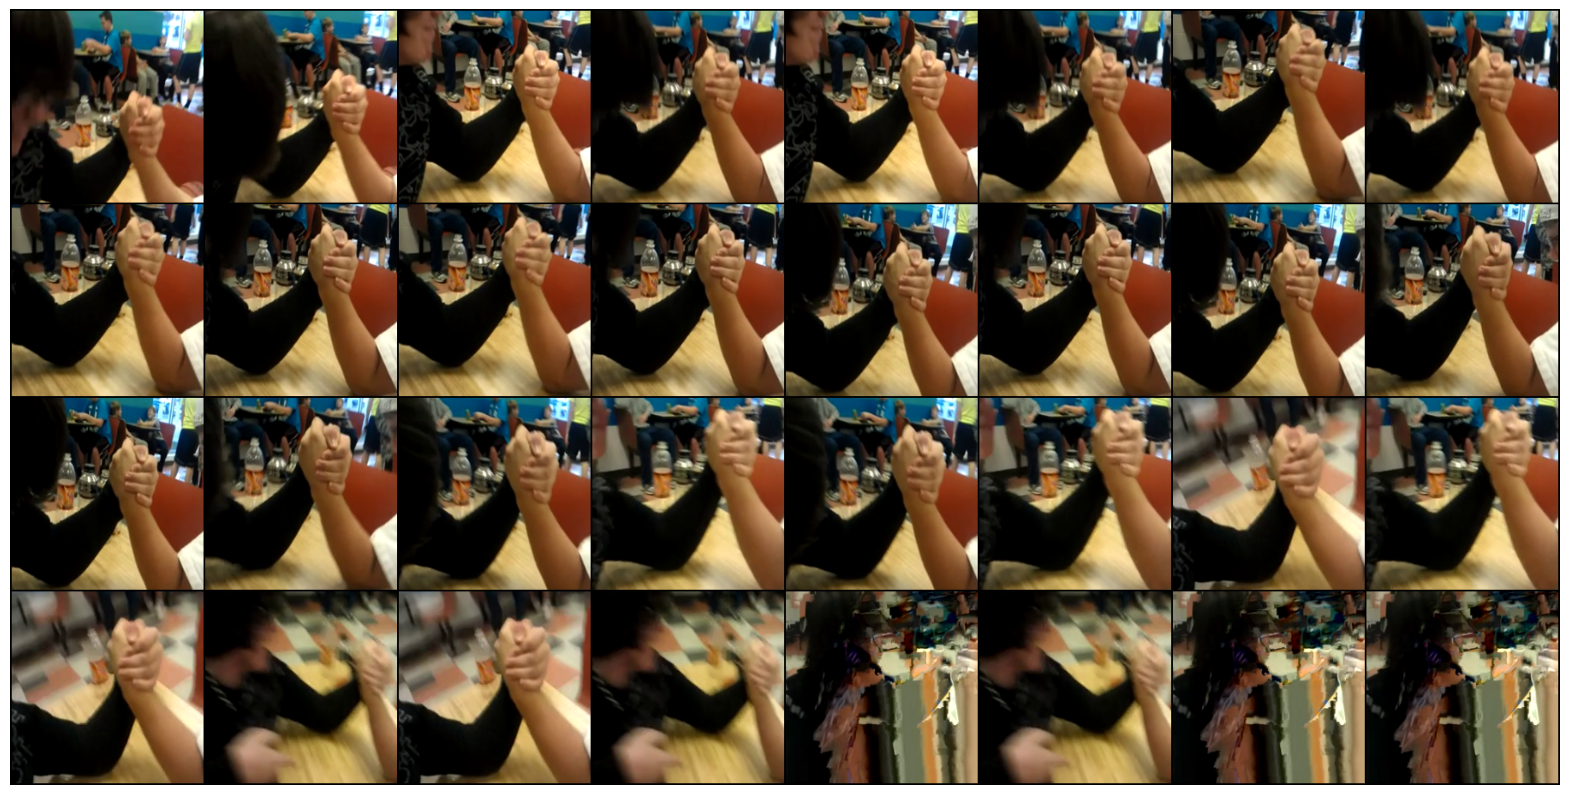

In [6]:
idx=0
n_clips,C,T,H,W=data['inputs'][idx].shape
print(f"{data['inputs'][idx].shape=}, {data['inputs'][idx].dtype}")
# from (n_clips,C,T,H,W) to (n_clips,T,C,H,W) to (n_clips*T,C,H,W)
sampled_imgs=data['inputs'][idx].permute(0,2,1,3,4).reshape(-1,C,H,W)[::10]  
print(f"{sampled_imgs.shape=}")

_, ax=plt.subplots(figsize=(20,20))
ax.imshow(make_grid(sampled_imgs, nrow=8).permute(1,2,0))
ax.axis("off")

In [7]:

# calling result=model.test_step(data)[0] which internall call data=self.data_preprocessor
print(recognizer.data_preprocessor, cfg.model.data_preprocessor)
with torch.no_grad(): preproc_data=recognizer.data_preprocessor(data)
print(f"{type(preproc_data)=}, {preproc_data.keys()}, {preproc_data['inputs'].shape}")

ActionDataPreprocessor() {'mean': [123.675, 116.28, 103.53], 'std': [58.395, 57.12, 57.375], 'format_shape': 'NCTHW'}
In mmaction.models.data_preprocessors.data_preprocessor.ActionDataPreprocessor.forward type(data)=<class 'dict'>
dict_keys(['inputs', 'data_samples'])
In mmaction.models.data_preprocessors.data_preprocessor.ActionDataPreprocessor.forward_onesample [x.shape for x in inputs]=[torch.Size([10, 3, 32, 224, 224])]
[<ActionDataSample(

    META INFORMATION
    img_shape:(224, 224)

    DATA FIELDS
    gt_label:tensor([-1])
) at 0x1eae0c8eb50>]
In mmaction.models.data_preprocessors.data_preprocessor.ActionDataPreprocessor.preprocess type(batch_inputs)=<class 'torch.Tensor'>, batch_inputs.shape=torch.Size([1, 10, 3, 32, 224, 224])
In mmaction.models.data_preprocessors.data_preprocessor.ActionDataPreprocessor.preprocess format_shape='NCTHW', view_shape=None
In mmaction.models.data_preprocessors.data_preprocessor.ActionDataPreprocessor.preprocess self.to_rgb=False, self._enable_no

In [8]:
#self._run_forward(data, mode='predict') which calls self.predict(inputs, data_samples, **kwargs)
with torch.no_grad():
    feats, predict_kwargs=recognizer.extract_feat(preproc_data['inputs'], test_mode=True)
print(f"{predict_kwargs=}")
print(f"{type(feats)=}, {len(feats)=}, {[x.shape for x in feats]=}")

inputs.shape=torch.Size([10, 3, 32, 224, 224])
predict_kwargs={}
type(feats)=<class 'tuple'>, len(feats)=2, [x.shape for x in feats]=[torch.Size([10, 2048, 4, 7, 7]), torch.Size([10, 256, 32, 7, 7])]


In [13]:
recognizer.cls_head.average_clips, preproc_data['inputs'].shape

('prob', torch.Size([1, 10, 3, 32, 224, 224]))

In [10]:
with torch.no_grad():
    # predictions=self.cls_head.predict(feats, data_samples, **predict_kwargs)
    cls_scores=recognizer.cls_head(feats, **predict_kwargs)
    print(f"{cls_scores.shape=}")
    predictions=recognizer.cls_head.predict_by_feat(cls_scores, preproc_data['data_samples'])[0]
    print(predictions.get('pred_label').item())

cls_scores.shape=torch.Size([10, 400])
In mmaction.models.heads.base.predict_by_feat num_segs=10, cls_scores.shape=torch.Size([10, 400])
In mmaction.models.heads.base.average_clip self.average_clips='prob' cls_scores.shape=torch.Size([10, 400])
In mmaction.models.heads.base.average_clip after reshape cls_scores.shape=torch.Size([1, 10, 400])
In mmaction.models.heads.base.average_clip before return cls_scores.shape=torch.Size([1, 400])
In mmaction.models.heads.base.predict_by_feat after calling average_clip cls_scores.shape=torch.Size([1, 400])
In mmaction.models.heads.base.predict_by_feat pred_labels.shape=torch.Size([1, 1])
6


In [11]:
labels = open(args.label).readlines()
labels = [x.strip() for x in labels]
print(f"{len(labels)}, {labels[:10]}")

400, ['abseiling', 'air drumming', 'answering questions', 'applauding', 'applying cream', 'archery', 'arm wrestling', 'arranging flowers', 'assembling computer', 'auctioning']


In [12]:
pred_scores=predictions.pred_score.tolist()
score_tuples=tuple(zip(range(len(pred_scores)), pred_scores))
score_sorted=sorted(score_tuples, key=itemgetter(1), reverse=True) # sort score_tuples by score (second column) from large to small
top5_label=score_sorted[:5] 
print(f"{top5_label=}") # (label, score)
results=[(labels[k[0]], k[1]) for k in top5_label]
print(f"{results}")

top5_label=[(6, 0.9999994039535522), (139, 1.0760012258970164e-07), (288, 8.627358738522162e-08), (279, 5.661976132387281e-08), (268, 5.49794592075159e-08)]
[('arm wrestling', 0.9999994039535522), ('getting a tattoo', 1.0760012258970164e-07), ('shaking hands', 8.627358738522162e-08), ('rock scissors paper', 5.661976132387281e-08), ('riding camel', 5.49794592075159e-08)]
